The cell below imports the libraries that are used, and loads the rideshare data set. Because we are only studying the rideshare data set in this report we only loaded that data set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('rideshare_kaggle.csv')
print("Datasets loaded successfully!")

Datasets loaded successfully!


The cell below loads the first 5 rows of data set so we can get a better picture of the overall data, confirm that the results we are getting from our code seem to align with the data, and see column names.

In [ ]:
df.head()

In [ ]:
#data cleaning
price = df['price'].dropna()
distance = df['distance'].dropna()
df = df[(df['distance'] >= 0.1) & (df['price'] >= 0.1)] 
df = df.drop_duplicates()
print({len(prices)}, {len(distance)})

Data Cleaning method #1: dropna()
-We used .dropna() in our data cleaning process because we did not want null values to be sampled from in our bootstrap confidence interval or visualizations for price and distance that are run later in our code. Using the code .dropna() removes empty cells from the column, and ensures that all sampled units have a value and are not skewing our data results. 

Data Cleaning method #2:  >= 0.1
-

Data Cleaning method #3: drop_duplicates()
-


In [ ]:
#Charlotte visualization 1:

round_unit = 0.01  
grouped = df.groupby(df["distance"])["prices"].mean()
plt.figure(figsize=(8,5))
plt.plot(grouped.index.values, grouped.values)

plt.xlabel("Distance")  
plt.ylabel("Total price")
plt.title("Ride distance vs Total price line plot")
plt.show()

In [31]:
#Charlotte vis 2
lyft = df["cab_type"].str.lower() == "lyft"
lyft = df["cab_type"].str.strip() == "lyft"
lyft = lyft[(lyft["distance"] > 0) & (lyft["price"] > 0)]
x = lyft["distance"].values
y = lyft["price"].values

#used chat gpt to help create Binned summary map to comp data
bin_size = 0.05  
lyft["distance"] = (lyft["distance"] / bin_size).round(0) * bin_size

group = lyft.groupby("distance")["price"].mean().sort_index()
x = group.index.values
y = group.values

plt.figure(figsize=(8,5))
plt.bar(x, y, width=bin_size * 0.9, color="blue", edgecolor="k")
plt.ylabel("Total Price")
plt.title("Distance vs Price for Lyft")
plt.show()

KeyError: 'distance'

### Cleaning 1: Keeping only the columns I need

For my part of the project, I only needed the cab type, ride type, price, and distance. I also used **dropna()** here to get rid of any rows with missing values so they wouldn’t interfere with the rest of the analysis.

In [4]:
rides = df[['cab_type', 'name', 'price', 'distance']].dropna()
rides.head()

,cab_type,name,price,distance
0,Lyft,Shared,5.0,0.44
1,Lyft,Lux,11.0,0.44
2,Lyft,Lyft,7.0,0.44
3,Lyft,Lux Black XL,26.0,0.44
4,Lyft,Lyft XL,9.0,0.44


Here I’m creating a smaller cleaned dataset with just the columns I actually need. I also used dropna() so missing values wouldn’t mess up later calculations.

In [33]:
(rides['distance'] == 0).sum()

np.int64(0)

The output shows there weren’t any rides with a distance of 0, so I didn’t need to remove anything here.

### Manipulation 1: Creating a price per mile variable

Here I created a new column called **price_per_mile** by dividing each ride’s total price by its distance. I made this because comparing total price alone isn’t that useful when rides are different lengths.

In [6]:
rides['price_per_mile'] = rides['price'] / rides['distance']
rides.head()

,cab_type,name,price,distance,price_per_mile
0,Lyft,Shared,5.0,0.44,11.363636
1,Lyft,Lux,11.0,0.44,25.000000
2,Lyft,Lyft,7.0,0.44,15.909091
3,Lyft,Lux Black XL,26.0,0.44,59.090909
4,Lyft,Lyft XL,9.0,0.44,20.454545


In [35]:
rides['name'].value_counts()

name
UberPool        8645
UberXL          8615
Black SUV       8609
WAV             8607
UberX           8605
Black           8603
Lux Black XL    8092
Shared          8078
Lux Black       8059
Lux             8055
Lyft            8054
Lyft XL         8051
Name: count, dtype: int64

Before making my boxplot, I checked which ride types were in the dataset so I could focus on a few specific Uber ride categories for comparison.

## Visualization 1: Price per mile by ride type

For this graph, I wanted to compare how expensive different Uber ride types are **per mile**, not just in total.

A boxplot works well here because it shows the center, spread, and outliers for each category instead of just giving one average.

/tmp/ipykernel_184/971798931.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([uberx, uberxl, black, wav], labels=['UberX', "UberXL", 'Black', 'WAV'])


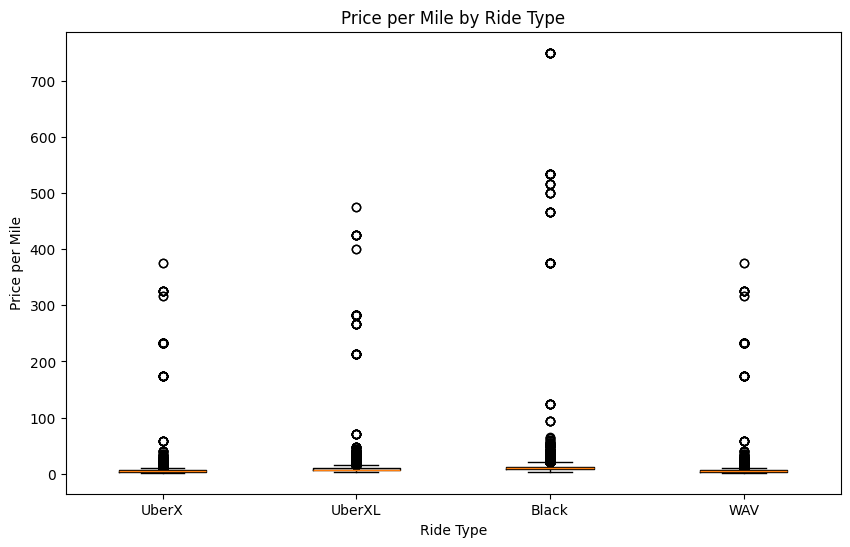

In [10]:
uberx = rides[rides['name'] == 'UberX']['price_per_mile']
uberxl = rides[rides['name'] == 'UberXL']['price_per_mile']
black = rides[rides['name'] == 'Black']['price_per_mile']
wav = rides[rides['name'] == 'WAV']['price_per_mile']

plt.figure(figsize=(10,6))
plt.boxplot([uberx, uberxl, black, wav], labels=['UberX', "UberXL", 'Black', 'WAV'])
plt.xlabel('Ride Type')
plt.ylabel('Price per Mile')
plt.title('Price per Mile by Ride Type')
plt.show()

### Cleaning 2: Trimming extreme outliers for the boxplot

Some rides had really extreme price-per-mile values, which stretched the boxplot and made it harder to compare the main ride types. I made a trimmed version of the data just for that graph so it would be easier to read.

In [16]:
rides2 = rides[rides['price_per_mile'] < 100]

/tmp/ipykernel_146/807559891.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([uberx, uberxl, black, wav], labels=['UberX', "UberXL", 'Black', 'WAV'])


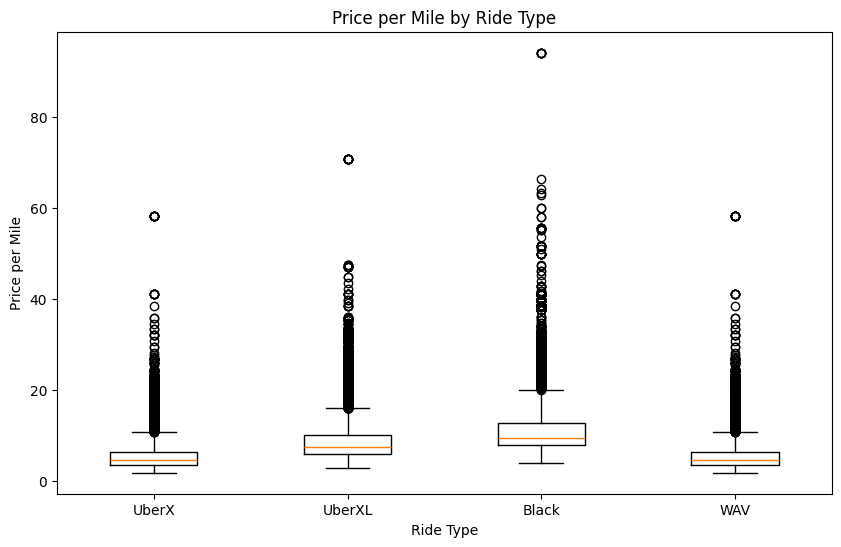

In [17]:
uberx = rides2[rides2['name'] == 'UberX']['price_per_mile']
uberxl = rides2[rides2['name'] == 'UberXL']['price_per_mile']
black = rides2[rides2['name'] == 'Black']['price_per_mile']
wav = rides2[rides2['name'] == 'WAV']['price_per_mile']

plt.figure(figsize=(10,6))
plt.boxplot([uberx, uberxl, black, wav], labels=['UberX', "UberXL", 'Black', 'WAV'])
plt.xlabel('Ride Type')
plt.ylabel('Price per Mile')
plt.title('Price per Mile by Ride Type')
plt.show()

This graph shows that the ride types are definitely not priced the same.

**Black** is clearly the most expensive per mile, while **UberX** and **WAV** are lower. **UberXL** is also higher than UberX, but not as high as Black.

So overall, this suggests that the more premium Uber ride options tend to cost more per mile than the more standard ones.

### Cleaning 3: Making an Uber-only dataset

Since my second visualization and my confidence interval focus specifically on Uber rides, I made a smaller version of the dataset that only includes Uber observations.

In [9]:
uber = rides[rides['cab_type'] == 'Uber']
uber.head()

## Visualization 2: Uber ride distance vs total price

For this graph, I wanted to see how ride distance relates to total Uber price.

A scatterplot makes sense here because both variables are numerical, and I wanted to see whether there was a pattern between them.

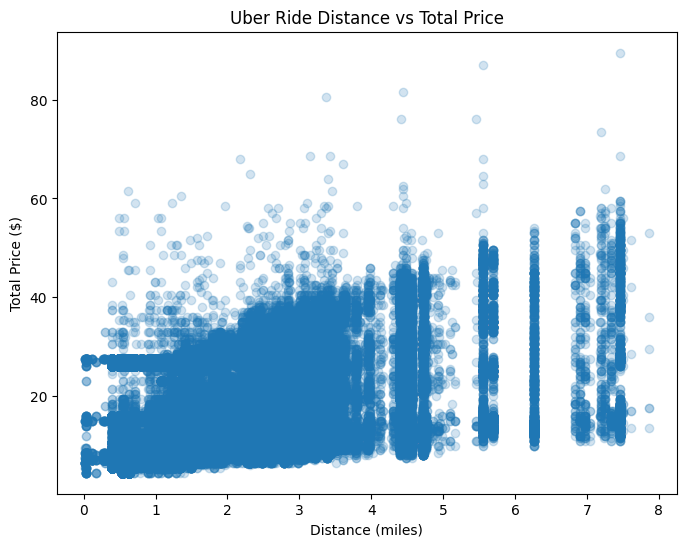

In [19]:
#Theo Visualization 3
plt.figure(figsize=(8,6))
plt.scatter(uber['distance'], uber['price'], alpha=0.2)
plt.xlabel('Distance (miles)')
plt.ylabel('Total Price ($)')
plt.title('Uber Ride Distance vs Total Price')
plt.show()

There’s a pretty clear positive relationship here: as distance goes up, total price usually goes up too.

At the same time, the points aren’t perfectly lined up, which means distance is definitely important, but it’s not the only thing affecting price.

That also helps explain why using **price per mile** is useful, because total price by itself doesn’t tell the whole story.

## Confidence interval: average Uber price per mile

For my confidence interval, I wanted to estimate the average **Uber price per mile** and see whether it could realistically be **$10 per mile**.

Instead of just taking one mean and stopping there, I used bootstrap sampling to create a **95% confidence interval**.

In [11]:
uber_ppm = uber['price_per_mile']
boot_means = np.array([
    uber_ppm.sample(len(uber_ppm), replace=True).mean()
    for _ in range(1000)
])

ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)

print("95% CI:", round(ci_lower, 2), "to", round(ci_upper, 2))

95% CI: 9.63 to 9.75


My 95% confidence interval came out to **9.63 to 9.75**.

That means I’m estimating that the true average Uber price per mile is probably somewhere in that range.

Since **10 dollars is not inside the interval**, that suggests the average Uber price per mile is probably **not equal to 10 dollars**, and is actually a little lower.

I also graphed the bootstrap distribution so I could actually see how the resampled means were spread out.

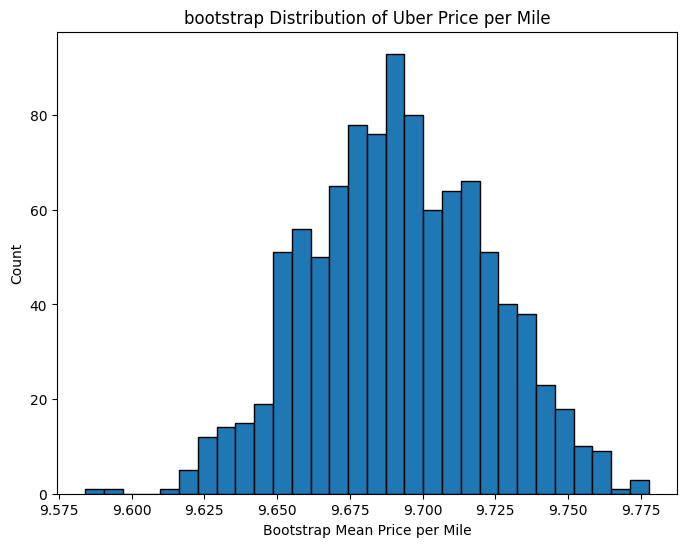

In [22]:
plt.figure(figsize=(8,6))
plt.hist(boot_means, bins=30, edgecolor='black')
plt.xlabel('Bootstrap Mean Price per Mile')
plt.ylabel('Count')
plt.title('bootstrap Distribution of Uber Price per Mile')
plt.show()

## Conclusion

Overall, my analysis shows that Uber pricing changes in pretty clear ways depending on both ride type and distance.

The boxplot showed that premium ride types like **Black** tend to cost more per mile than standard ones like **UberX**. The scatterplot showed that longer rides usually cost more overall, but not perfectly, which is why **price per mile** was a useful variable to create.

Finally, my confidence interval suggested that the average Uber price per mile is likely between **9.63 and 9.75**, which is slightly lower than **$10 per mile**.

## AI Statement

### Dataset used
Uber/Lyft rideshare dataset

### What I used AI for
- clarifying how bootstrap confidence intervals work
- light editing of explanations for readability

### Why I used it
I mainly used AI to better understand the bootstrap method and to help make a few explanations clearer, but all of the code, analysis, and conclusions were done by me.

In [ ]:
#Charlotte CI
H0 = 10.0 

df = df[(df["distance"] > 0) & (df['price'] > 0)].copy()
df["price"] = df['price'] / df["distance"]
n = len(x)
obs_mean = x.mean()

rng = np.random.default_rng(123)
n_boot = 5000
boot_means = np.empty(n_boot)
for i in range(n_boot):
    boot_means[i] = random.choices(x, size=n, replace=True).mean()

ci_lower, ci_upper = np.percentile(boot_means, [2.5, 97.5])

mu0 = 10.0
boot_shifted = boot_means - boot_means.mean() + mu0
p_value = np.mean(np.abs(boot_shifted - mu0) >= abs(obs_mean - mu0))

print(f"n = {n}, mean = {obs_mean:.3f}")
print(f"95% CI = ({ci_lower:.3f}, {ci_upper:.3f}), p value = {p_value:.3f}")
if p_value < 0.05:
    print("Conclusion: reject H0 mean not equal to", mu0)
else:
    print("Conclusion: do not reject H0 mean equal to", mu0)
    
#p is low ~(0) so we reject the H0


In [ ]:
#Charlotte additional CI 
df = df.dropna(subset=["cab_type", "distance", "price"])
df = df[(df["distance"] > 0) & (df["price"] > 0)].copy()
df["price_per_mile"] = df["price"] / df["distance"]

uber = df["cab_type"].str.lower() == "uber"]["price_per_mile"].values
uber = df["cab_type"].str.strip() == "uber"]["price_per_mile"].values
lyft = df["cab_type"].str.lower() == "lyft"]["price_per_mile"].values
lyft = df["cab_type"].str.strip() == "lyft"]["price_per_mile"].values

n_uber = len(uber)
n_lyft = len(lyft)

obs_diff = uber.mean() - lyft.mean()

rng = np.random.default_rng(123)
n_boot = 5000
boot_diffs = []
for i in range(n_boot):
samp_uber = rng.choice(uber, size=n_uber, replace=True)
samp_lyft = rng.choice(lyft, size=n_lyft, replace=True)
boot_diffs.append(samp_uber.mean() - samp_lyft.mean())

ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])
mu0 = 0.05
boot_shifted = boot_diffs - boot_diffs.mean() + mu0
p_value = np.mean(np.abs(boot_shifted - mu0) >= abs(obs_diff - mu0))

print(f"n Uber = {n_uber}, n Lyft = {n_lyft}")
print(f"observed diff (uber - lyft) = {obs_diff:.4f}")
print(f"95% bootstrap CI = ({ci_lower:.4f}, {ci_upper:.4f}), p value = {p_value:.4f}")
if p_value < 0.05:
    print("Reject H0 mean difference not equal to", mu0)
else:
    print("Do not reject H0 mean difference equal to", mu0)